<a href="https://colab.research.google.com/github/mkbhuva/-HealthCare-Monitoring-System_AI/blob/main/HealthCare_Monitoring_System_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np

df = pd.read_csv('diabetes_data.csv')

print(df.shape)

print(df.head())

print(df.info())

print(df.isnull().sum())

print(df.describe())

print(df['Diabetes_012'].value_counts())

print(df['Diabetes_012'].value_counts(normalize=True))

(253680, 22)
   Diabetes_012  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0           0.0     1.0       1.0        1.0  40.0     1.0     0.0   
1           0.0     0.0       0.0        0.0  25.0     1.0     0.0   
2           0.0     1.0       1.0        1.0  28.0     0.0     0.0   
3           0.0     1.0       0.0        1.0  27.0     0.0     0.0   
4           0.0     1.0       1.0        1.0  24.0     0.0     0.0   

   HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
0                   0.0           0.0     0.0  ...            1.0   
1                   0.0           1.0     0.0  ...            0.0   
2                   0.0           0.0     1.0  ...            1.0   
3                   0.0           1.0     1.0  ...            1.0   
4                   0.0           1.0     1.0  ...            1.0   

   NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex   Age  Education  \
0          0.0      5.0      18.0      15.0       1.0  0.0   9.0        

In [7]:
df['Diabetes'] = df['Diabetes_012'].replace({0:0,1:1,2:1})

df = df.drop('Diabetes_012',axis=1)

print(df['Diabetes'].value_counts())

print(df['Diabetes'].value_counts(normalize=True))

Diabetes
0.0    213703
1.0     39977
Name: count, dtype: int64
Diabetes
0.0    0.842412
1.0    0.157588
Name: proportion, dtype: float64


In [8]:
X = df.drop('Diabetes',axis=1)

y = df['Diabetes']

print(X.shape)

print(y.shape)

(253680, 21)
(253680,)


In [9]:
df = df.drop_duplicates()

print(df.shape)

(229712, 22)


In [10]:
df = df.dropna()

print(df.isnull().sum())

HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
Diabetes                0
dtype: int64


In [11]:
binary_cols = ['HighBP','HighChol','CholCheck','Smoker','Stroke','HeartDiseaseorAttack','PhysActivity','Fruits','Veggies','HvyAlcoholConsump','AnyHealthcare','NoDocbcCost','DiffWalk','Sex','Diabetes']

for col in binary_cols:
    df[col] = df[col].astype(int)

In [12]:
ordinal_cols = ['GenHlth','Education','Income','Age']

for col in ordinal_cols:
    df[col] = df[col].astype(int)

In [13]:
cont_cols = ['BMI','MentHlth','PhysHlth']

for col in cont_cols:
    df[col] = df[col].astype(float)

In [14]:
X = df.drop('Diabetes',axis=1)

y = df['Diabetes']

In [15]:
df['BMI_Category'] = pd.cut(df['BMI'],
bins=[0,18.5,25,30,100],
labels=[0,1,2,3])

df['BMI_Category'] = df['BMI_Category'].astype(int)

In [16]:
df['Age_Group'] = pd.cut(df['Age'],
bins=[0,4,8,11,13],
labels=[0,1,2,3])

df['Age_Group'] = df['Age_Group'].astype(int)

In [17]:
X = df.drop('Diabetes',axis=1)

y = df['Diabetes']
print(X.shape)

(229712, 23)


In [18]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
X,
y,
test_size=0.2,
random_state=42,
stratify=y
)

print(X_train.shape)
print(X_test.shape)

(183769, 23)
(45943, 23)


In [19]:
!pip install imbalanced-learn

In [20]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote,y_train_smote = smote.fit_resample(X_train, y_train)

print(y_train.value_counts())
print(y_train_smote.value_counts())

Diabetes
0    152044
1     31725
Name: count, dtype: int64
Diabetes
1    152044
0    152044
Name: count, dtype: int64


In [21]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

In [22]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)
print(y_train_smote.shape)
print(y_test.shape)

(304088, 23)
(45943, 23)
(304088,)
(45943,)


In [23]:
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [24]:
lr = LogisticRegression(max_iter=2000)

lr.fit(X_train_scaled,y_train_smote)

LogisticRegression(max_iter=2000)

In [25]:
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:,1]

In [26]:
print(classification_report(y_test,y_pred_lr))
print("ROC-AUC:",roc_auc_score(y_test,y_prob_lr))

              precision    recall  f1-score   support

           0       0.91      0.71      0.80     38011
           1       0.33      0.67      0.44      7932

    accuracy                           0.71     45943
   macro avg       0.62      0.69      0.62     45943
weighted avg       0.81      0.71      0.74     45943

ROC-AUC: 0.7635266335369411


In [27]:
results = {}

results['Logistic Regression'] = [
accuracy_score(y_test,y_pred_lr),
precision_score(y_test,y_pred_lr),
recall_score(y_test,y_pred_lr),
f1_score(y_test,y_pred_lr),
roc_auc_score(y_test,y_prob_lr)
]

print(results)

{'Logistic Regression': [0.7064623555275015, 0.32770815237622536, 0.6659102370146243, 0.43925155925155923, np.float64(0.7635266335369411)]}


In [28]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_scaled,y_train_smote)

RandomForestClassifier(max_depth=12, min_samples_split=5, n_estimators=300,
                       n_jobs=-1, random_state=42)

In [29]:
y_pred_rf = rf.predict(X_test_scaled)
y_prob_rf = rf.predict_proba(X_test_scaled)[:,1]

In [30]:
print(classification_report(y_test,y_pred_rf))
print("ROC-AUC:",roc_auc_score(y_test,y_prob_rf))

              precision    recall  f1-score   support

           0       0.92      0.72      0.81     38011
           1       0.34      0.70      0.46      7932

    accuracy                           0.72     45943
   macro avg       0.63      0.71      0.63     45943
weighted avg       0.82      0.72      0.75     45943

ROC-AUC: 0.7833253818436426


In [31]:
print(accuracy_score(y_test,y_pred_rf))

print(precision_score(y_test,y_pred_rf))

print(recall_score(y_test,y_pred_rf))

print(f1_score(y_test,y_pred_rf))

print(roc_auc_score(y_test,y_pred_rf))

0.7183684130335416
0.3440478415249486
0.6962934947049925
0.46053783614759225
0.7096342115076093


In [32]:
print(confusion_matrix(y_test,y_pred_rf))

[[27481 10530]
 [ 2409  5523]]


In [33]:
print(classification_report(y_test,y_pred_rf))

              precision    recall  f1-score   support

           0       0.92      0.72      0.81     38011
           1       0.34      0.70      0.46      7932

    accuracy                           0.72     45943
   macro avg       0.63      0.71      0.63     45943
weighted avg       0.82      0.72      0.75     45943



In [34]:
results['Random Forest'] = [
accuracy_score(y_test,y_pred_rf),
precision_score(y_test,y_pred_rf),
recall_score(y_test,y_pred_rf),
f1_score(y_test,y_pred_rf),
roc_auc_score(y_test,y_pred_rf)
]

print(results)

{'Logistic Regression': [0.7064623555275015, 0.32770815237622536, 0.6659102370146243, 0.43925155925155923, np.float64(0.7635266335369411)], 'Random Forest': [0.7183684130335416, 0.3440478415249486, 0.6962934947049925, 0.46053783614759225, np.float64(0.7096342115076093)]}


In [35]:
!pip install xgboost

In [36]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
n_estimators=400,
max_depth=6,
learning_rate=0.05,
subsample=0.8,
colsample_bytree=0.8,
random_state=42,
n_jobs=-1
)

xgb.fit(X_train_scaled,y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=400,
              n_jobs=-1, num_parallel_tree=None, ...)

In [37]:
y_pred_xgb = xgb.predict(X_test_scaled)
y_prob_xgb = xgb.predict_proba(X_test_scaled)[:,1]

In [38]:
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

              precision    recall  f1-score   support

           0       0.90      0.80      0.85     38011
           1       0.37      0.56      0.44      7932

    accuracy                           0.76     45943
   macro avg       0.63      0.68      0.64     45943
weighted avg       0.81      0.76      0.78     45943

ROC-AUC: 0.7717751515330256


In [39]:
print(accuracy_score(y_test,y_pred_xgb))

print(precision_score(y_test,y_pred_xgb))

print(recall_score(y_test,y_pred_xgb))

print(f1_score(y_test,y_pred_xgb))

print(roc_auc_score(y_test,y_pred_xgb))

0.7585486363537427
0.36834652228238235
0.5574886535552194
0.44359733159452275
0.6789968852475263


In [40]:
print(confusion_matrix(y_test,y_pred_xgb))

[[30428  7583]
 [ 3510  4422]]


In [41]:
print(classification_report(y_test,y_pred_xgb))

              precision    recall  f1-score   support

           0       0.90      0.80      0.85     38011
           1       0.37      0.56      0.44      7932

    accuracy                           0.76     45943
   macro avg       0.63      0.68      0.64     45943
weighted avg       0.81      0.76      0.78     45943



In [42]:
results['XGBoost'] = [
accuracy_score(y_test,y_pred_xgb),
precision_score(y_test,y_pred_xgb),
recall_score(y_test,y_pred_xgb),
f1_score(y_test,y_pred_xgb),
roc_auc_score(y_test,y_pred_xgb)
]

print(results)

{'Logistic Regression': [0.7064623555275015, 0.32770815237622536, 0.6659102370146243, 0.43925155925155923, np.float64(0.7635266335369411)], 'Random Forest': [0.7183684130335416, 0.3440478415249486, 0.6962934947049925, 0.46053783614759225, np.float64(0.7096342115076093)], 'XGBoost': [0.7585486363537427, 0.36834652228238235, 0.5574886535552194, 0.44359733159452275, np.float64(0.6789968852475263)]}


In [43]:
import pandas as pd

results_df = pd.DataFrame(results).T

results_df.columns = [
'Accuracy',
'Precision',
'Recall',
'F1',
'ROC'
]

print(results_df)

                     Accuracy  Precision    Recall        F1       ROC
Logistic Regression  0.706462   0.327708  0.665910  0.439252  0.763527
Random Forest        0.718368   0.344048  0.696293  0.460538  0.709634
XGBoost              0.758549   0.368347  0.557489  0.443597  0.678997


In [44]:
results_df.sort_values('ROC',ascending=False)

,Accuracy,Precision,Recall,F1,ROC
Logistic Regression,0.706462,0.327708,0.665910,0.439252,0.763527
Random Forest,0.718368,0.344048,0.696293,0.460538,0.709634
XGBoost,0.758549,0.368347,0.557489,0.443597,0.678997


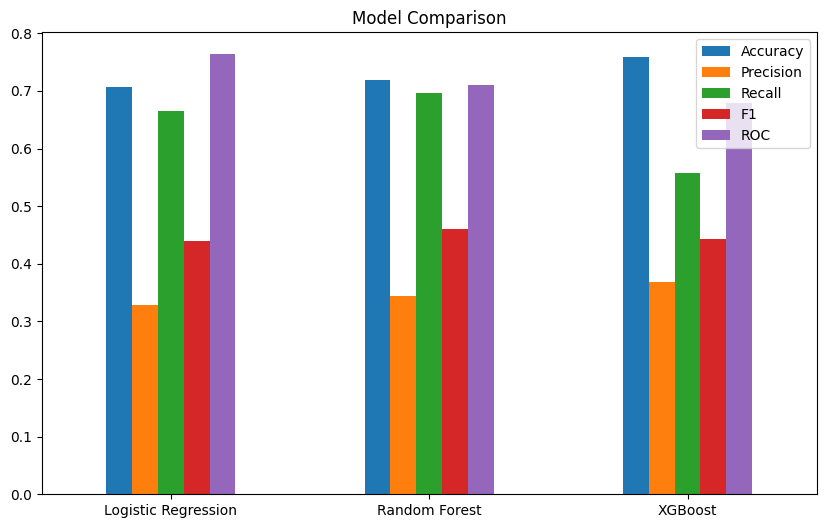

In [45]:
import matplotlib.pyplot as plt

results_df.plot(kind='bar',figsize=(10,6))

plt.xticks(rotation=0)

plt.title("Model Comparison")

plt.show()

In [46]:
!pip install seaborn

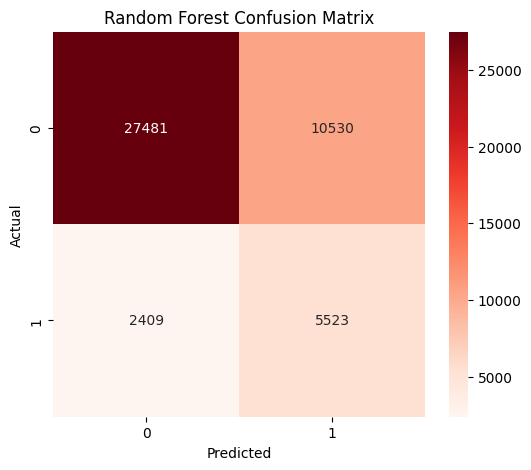

In [47]:
import seaborn as sns

cm = confusion_matrix(y_test,y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(cm,annot=True,fmt='d',cmap='Reds')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Random Forest Confusion Matrix")

plt.show()

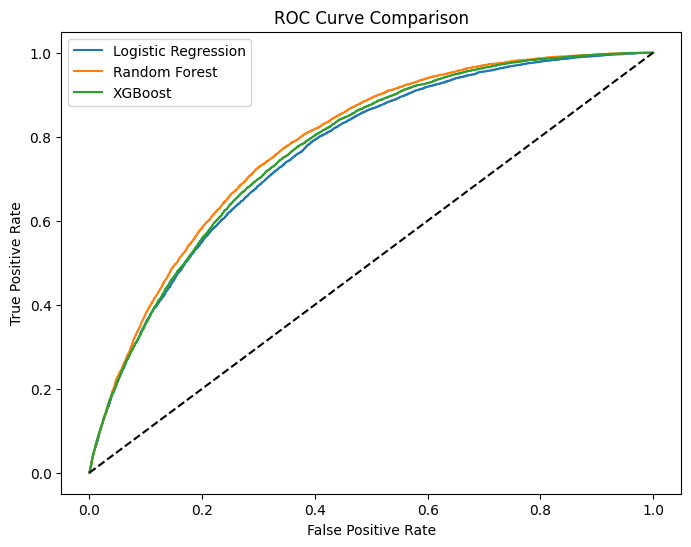

In [48]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

lr_fpr, lr_tpr, _ = roc_curve(y_test, y_prob_lr)
rf_fpr, rf_tpr, _ = roc_curve(y_test, y_prob_rf)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(8,6))

plt.plot(lr_fpr, lr_tpr, label='Logistic Regression')
plt.plot(rf_fpr, rf_tpr, label='Random Forest')
plt.plot(xgb_fpr, xgb_tpr, label='XGBoost')

plt.plot([0,1],[0,1],'k--')

plt.legend()
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.show()

In [49]:
models = {
    "Logistic Regression": y_prob_lr,
    "Random Forest": y_prob_rf,
    "XGBoost": y_prob_xgb
}

for name, probs in models.items():
    print(name, roc_auc_score(y_test, probs))

Logistic Regression 0.7635266335369411
Random Forest 0.7833253818436426
XGBoost 0.7717751515330256


In [50]:
best_model = rf
best_probs = y_prob_rf

In [51]:
from sklearn.metrics import precision_recall_curve
import numpy as np

precision, recall, thresholds = precision_recall_curve(y_test, y_prob_rf)

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)

best_idx = np.argmax(f1_scores)
threshold = thresholds[best_idx]

print("Best Threshold:", threshold)

Best Threshold: 0.521882420469922


In [52]:
y_pred_final = (y_prob_rf > threshold).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       0.91      0.75      0.82     38011
           1       0.36      0.66      0.46      7932

    accuracy                           0.73     45943
   macro avg       0.63      0.71      0.64     45943
weighted avg       0.82      0.73      0.76     45943



In [53]:
feature_importance = pd.DataFrame({'Feature':X.columns, 'Importance':rf.feature_importances_ })

feature_importance = feature_importance.sort_values('Importance', ascending=False)
feature_importance.head(15)

,Feature,Importance
3,BMI,0.166896
13,GenHlth,0.150743
18,Age,0.105277
0,HighBP,0.092272
22,Age_Group,0.067098
21,BMI_Category,0.066235
7,PhysActivity,0.054189
20,Income,0.048150
15,PhysHlth,0.041336
19,Education,0.038732


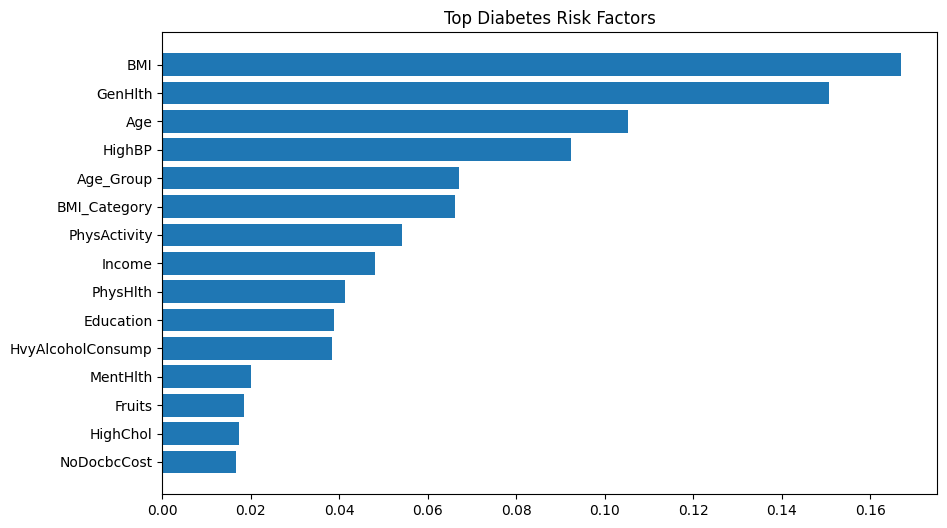

In [54]:
plt.figure(figsize=(10,6))

plt.barh(

feature_importance['Feature'][:15],

feature_importance['Importance'][:15]

)

plt.gca().invert_yaxis()

plt.title("Top Diabetes Risk Factors")

plt.show()

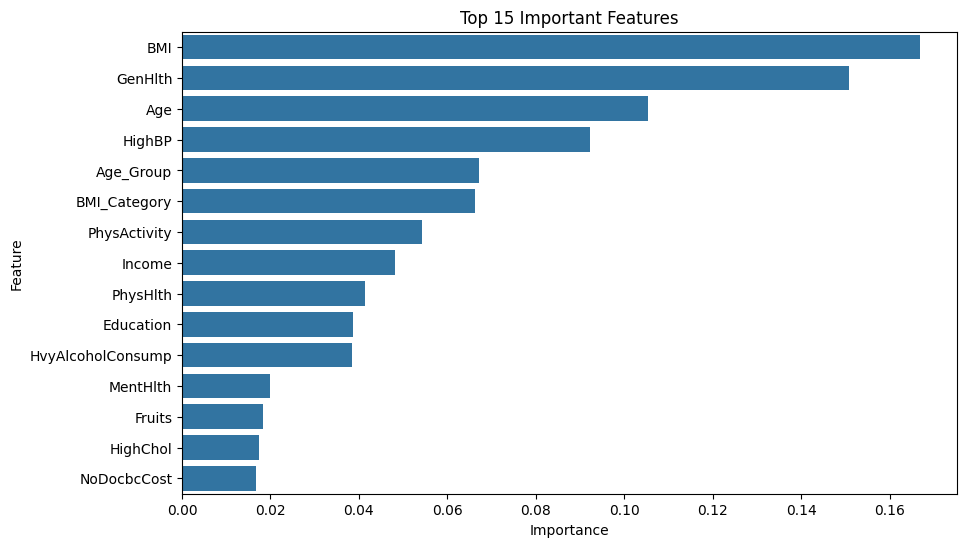

In [55]:
plt.figure(figsize=(10,6))

sns.barplot(

x='Importance',

y='Feature',

data=feature_importance.head(15)

)

plt.title("Top 15 Important Features")

plt.show()

In [56]:
!pip install joblib

In [57]:
if hasattr(best_model, "feature_importances_"):
    importance = best_model.feature_importances_

elif hasattr(best_model, "coef_"):
    importance = np.abs(best_model.coef_[0])

else:
    importance = np.zeros(len(X.columns))

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

In [58]:
import joblib

feature_names = X.columns.tolist()

joblib.dump(best_model, 'diabetes_model1.pkl')
joblib.dump(scaler, 'scaler2.pkl')
joblib.dump(feature_names, 'features3.pkl')
joblib.dump(threshold, 'threshold4.pkl')
joblib.dump(importance_df, 'feature_importance5.pkl')

['feature_importance5.pkl']

In [59]:
importance = pd.DataFrame({

'feature':X.columns,

'importance':best_model.feature_importances_

})

importance = importance.sort_values(
'importance',
ascending=False
)

importance.to_csv(
"feature_importance5.csv",
index=False
)